In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

from daart.eval import get_precision_recall
from daart_utils.paths import data_path, results_path
from daart_utils.data import DataHandler

In [41]:
from daart_utils.utils import smooth_interpolate_signal_sg
def smooth_interpolate_features(features, window=11, order=3, interp_kind='linear'):
    features_tmp = np.copy(features.vals)
    # get rid of low-likelihood markers
    for idx, name in enumerate(features.names):
        features_tmp[:, idx] = smooth_interpolate_signal_sg(
            features_tmp[:, idx], window=window, order=order, interp_kind=interp_kind
        )
    return features_tmp

In [90]:
# select dataset
dataset = 'mouse-oft-aligned'

if dataset == 'fish':
    from daart_utils.session_ids.fish import SESS_IDS_ALL as sess_ids
    raise NotImplementedError
elif dataset == 'fly' or dataset == 'fly-5':
    from daart_utils.session_ids.fly import SESS_IDS_ALL as sess_ids
elif dataset == 'ibl':
    from daart_utils.session_ids.ibl import SESS_IDS_ALL as sess_ids
elif dataset == 'mouse-oft-aligned':
    from daart_utils.session_ids.oft import SESS_IDS_ALL as sess_ids
elif dataset == 'resident-intruder-old':
    from daart_utils.session_ids.resident_intruder import SESS_IDS_ALL as sess_ids
elif dataset == 'resident-intruder':
    from daart_utils.session_ids.resident_intruder import SESS_IDS_ALL as sess_ids
elif dataset == 'calms21':
    from daart_utils.session_ids.calms21 import SESS_IDS_ALL as sess_ids
    
else:
    raise NotImplementedError
    
base_path = os.path.join(data_path, dataset)
save_path = os.path.join(data_path, dataset)    

use_features = True

for sess_id in sess_ids[1:]:

    print(sess_id)

    # initialize data handler; point to correct base path
    handler = DataHandler(sess_id, base_path=base_path)
    # handler.load_hand_labels()
    if use_features:
        dirname = 'features-sturman'
        handler.load_features(dirname=dirname)
    else:
        dirname = 'features'
        handler.load_markers()

    if dataset == 'ibl':
        markers = np.load(os.path.join(base_path, 'markers', '%s_labeled.npy' % sess_id))
        velocity = np.vstack([np.array([0, 0, 0]), np.diff(markers, axis=0)])
        features = [markers, velocity]
        feature_names = [
            'paw_x_pos', 'paw_y_pos', 'wheel_vel', 'paw_x_vel', 'paw_y_vel', 'wheel_acc']
    else:
        if dataset == 'fly' or dataset == 'mouse-oft-aligned':
            window = 7
        else:
            window = 11
            
        if use_features:
            features_sm = smooth_interpolate_features(
                handler.features, window=window, order=3, interp_kind='linear')
            
            features = []
            feature_names = []
            for idx, name in enumerate(handler.features.names):
                # original feature
                features.append(handler.features.vals[:, idx, None])
                feature_names.append(name)
                # change in feature
                features.append(np.concatenate([
                    np.array([0]), 
                    np.diff(features_sm[:, idx], axis=0)
                ])[:, None])
                feature_names.append('%s_vel' % name)

        else:
            markers_sm = handler.markers.smooth_interpolate_sg(
                window=window, order=3, interp_kind='linear', likelihood_thresh=0.25)

            features = []
            feature_names = []
            for key, val in markers_sm.items():
                # position
                features.append(val)
                feature_names.append('%s_x_pos' % key)
                feature_names.append('%s_y_pos' % key)
                # change in position
                features.append(np.vstack([np.array([0, 0]), np.diff(val, axis=0)]))
                feature_names.append('%s_x_vel' % key)
                feature_names.append('%s_y_vel' % key)
    
    df = pd.DataFrame(np.hstack(features), columns=feature_names) 
    
    posvel_dir = os.path.join(save_path, f'{dirname}-posvel')
    if not os.path.exists(posvel_dir):
        os.makedirs(posvel_dir)
    df.to_csv(os.path.join(posvel_dir, '%s_labeled.csv' % sess_id))


OFT_6
OFT_11
OFT_12
OFT_14
OFT_15
OFT_16
OFT_23
OFT_24
OFT_38
OFT_39
OFT_41
OFT_43
OFT_44
OFT_49
OFT_50
OFT_51
OFT_52
OFT_54
OFT_58


In [74]:
# handler.markers.names

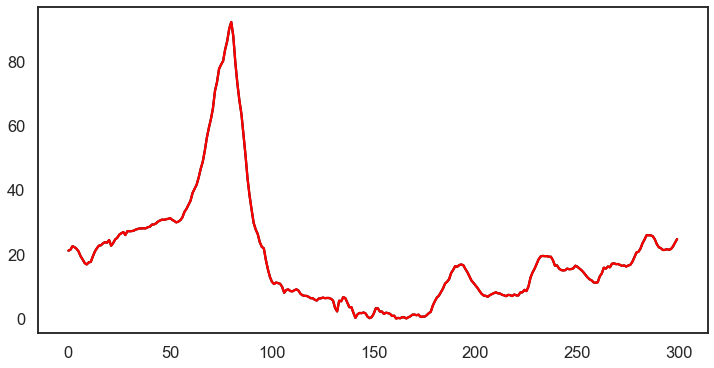

In [101]:
sns.set_context('talk')
sns.set_style('white')

# bp_name = 'Center_1'
# bp_name = 'fore-top'

# slc = (1000, 2000)
slc = (1500, 1800)
plt.figure(figsize=(12, 6))
if use_features:
    idx = -1
    plt.plot(handler.features.vals[slice(*slc), idx], 'k')
#     plt.plot(features_sm[slice(*slc), idx], 'r')
    plt.plot(features[2 * idx][slice(*slc)], 'r')
else:
    plt.plot(handler.markers.vals[bp_name][slice(*slc), 0], 'k')
    plt.plot(markers_sm[bp_name][slice(*slc), 0], 'r')

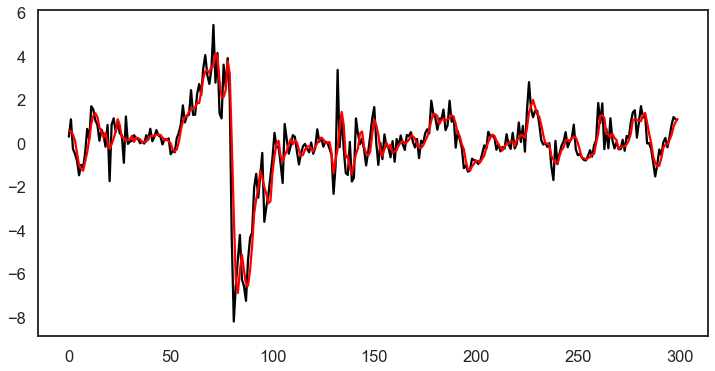

In [102]:
# slc = (0, 500)
plt.figure(figsize=(12, 6))
if use_features:
    plt.plot(np.diff(handler.features.vals[slice(*slc), idx]), 'k')
#     plt.plot(np.diff(features_sm[slice(*slc), idx]), 'r')
    plt.plot(features[2 * idx + 1][slice(*slc)], 'r')
else:
    plt.plot(np.diff(handler.markers.vals[bp_name][slice(*slc), 0]), 'k')
    plt.plot(np.diff(markers_sm[bp_name][slice(*slc), 0]), 'r')

In [3]:
# t = df.loc[:, 'abdomen_me'].to_numpy()
# t = df.loc[:, 'body_pixels'].to_numpy()
# t = pixels[:, 2] / pixels[:, 3]

# plt.figure()
# plt.plot(t[:500])
# plt.show()